<a href="https://colab.research.google.com/github/AdithiJRao/Student-Performance-Prediction-/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [72]:
df = pd.read_csv('student-mat.csv', sep=';')

In [96]:
print(df.shape)

print(df.columns)

df.info()

(395, 34)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'result'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   famsize     395 non-null    int64
 5   Pstatus     395 non-null    int64
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    int64
 9   Fjob        395 non-null    int64
 10  reason      395 n

In [97]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [98]:
df['result'] = df['G3'].apply(
    lambda x: 1 if x >= 10 else 0
)

df[['G3', 'result']].head()

,G3,result
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [99]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,result
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


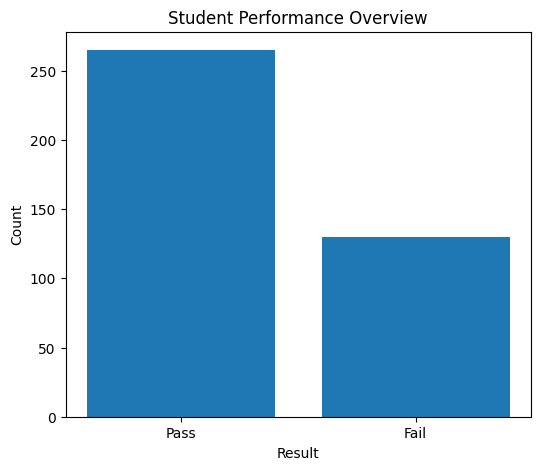

In [100]:
pass_count = df['result'].value_counts()

labels = ['Pass', 'Fail']

plt.figure(figsize=(6,5))

plt.bar(labels, pass_count)

plt.title('Student Performance Overview')

plt.xlabel('Result')

plt.ylabel('Count')

plt.show()

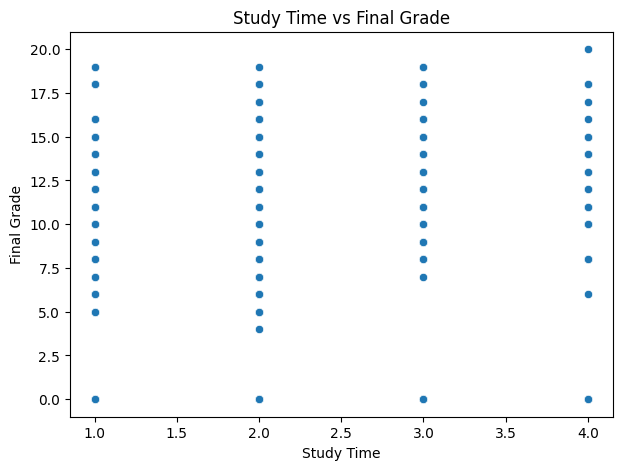

In [101]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['studytime'],
    y=df['G3']
)

plt.title('Study Time vs Final Grade')

plt.xlabel('Study Time')

plt.ylabel('Final Grade')

plt.show()

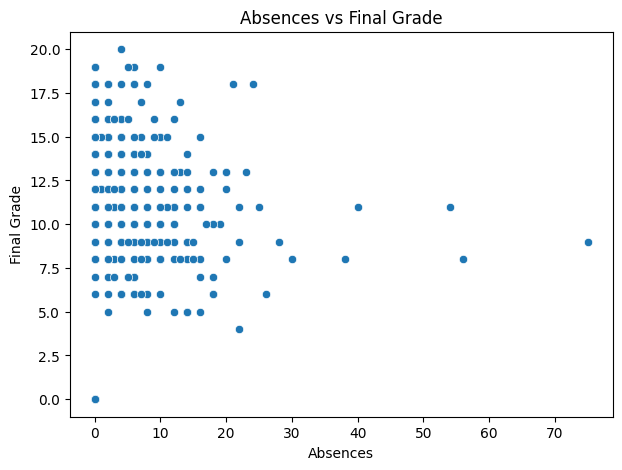

In [102]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['absences'],
    y=df['G3']
)

plt.title('Absences vs Final Grade')

plt.xlabel('Absences')

plt.ylabel('Final Grade')

plt.show()

In [103]:
X = df.drop(['G3', 'result'], axis=1)

y = df['result']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [107]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [108]:
def evaluate_model(y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1

In [109]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Naive Bayes',
        'SVM'
    ],

    'Accuracy': [

        evaluate_model(y_test, y_pred_lr)[0],

        evaluate_model(y_test, y_pred_dt)[0],

        evaluate_model(y_test, y_pred_nb)[0],

        evaluate_model(y_test, y_pred_svm)[0]
    ],

    'Precision': [

        evaluate_model(y_test, y_pred_lr)[1],

        evaluate_model(y_test, y_pred_dt)[1],

        evaluate_model(y_test, y_pred_nb)[1],

        evaluate_model(y_test, y_pred_svm)[1]
    ],

    'Recall': [

        evaluate_model(y_test, y_pred_lr)[2],

        evaluate_model(y_test, y_pred_dt)[2],

        evaluate_model(y_test, y_pred_nb)[2],

        evaluate_model(y_test, y_pred_svm)[2]
    ],

    'F1 Score': [

        evaluate_model(y_test, y_pred_lr)[3],

        evaluate_model(y_test, y_pred_dt)[3],

        evaluate_model(y_test, y_pred_nb)[3],

        evaluate_model(y_test, y_pred_svm)[3]
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.936709   0.960784  0.942308  0.951456
1        Decision Tree  0.886076   0.921569  0.903846  0.912621
2          Naive Bayes  0.873418   0.888889  0.923077  0.905660
3                  SVM  0.873418   0.875000  0.942308  0.907407


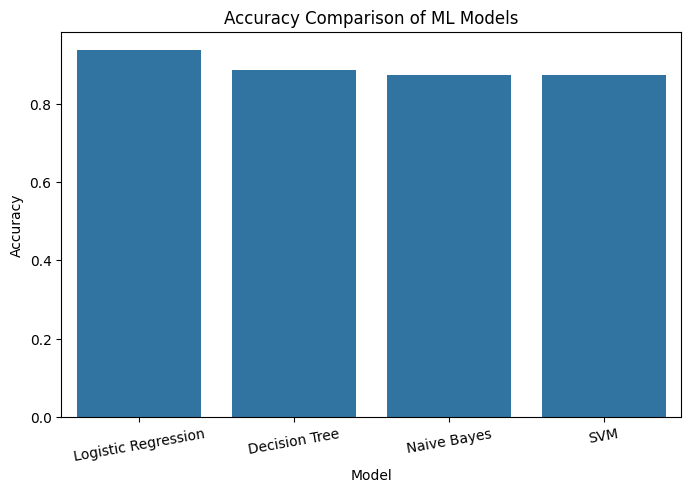

In [110]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Accuracy Comparison of ML Models')

plt.xticks(rotation=10)

plt.show()

In [119]:
results['Combined Score'] = (
    results['Accuracy'] +
    results['F1 Score']
) / 2

best_model = results.loc[
    results['Combined Score'].idxmax()
]

print("\n===================================")
print("BEST MODEL")
print("===================================")

print(best_model)


BEST MODEL
Model             Logistic Regression
Accuracy                     0.936709
Precision                    0.960784
Recall                       0.942308
F1 Score                     0.951456
Combined Score               0.944083
Name: 0, dtype: object


In [120]:
best_classifier = lr

best_predictions = y_pred_lr

In [124]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

print(cm)

[[25  2]
 [ 3 49]]


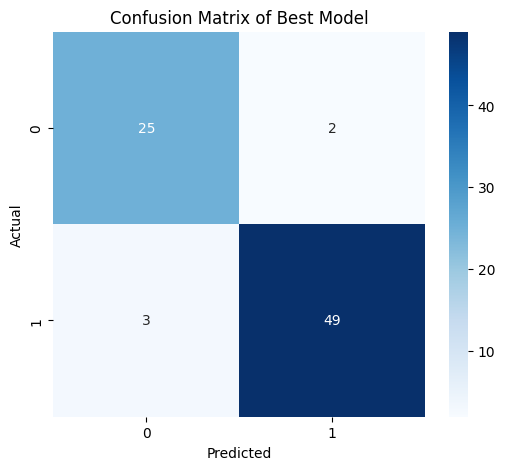

In [125]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix of Best Model')

plt.show()

In [126]:
print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        27
           1       0.96      0.94      0.95        52

    accuracy                           0.94        79
   macro avg       0.93      0.93      0.93        79
weighted avg       0.94      0.94      0.94        79



In [123]:
sample_student = X.iloc[0:1]

sample_student_scaled = scaler.transform(
    sample_student
)

prediction = best_classifier.predict(
    sample_student_scaled
)

actual_grade = df.iloc[0]['G3']

print("Predicted Result:")

if prediction[0] == 1:

    print("Pass")

else:

    print("Fail")

print("\nPredicted Grade Category:")

if actual_grade >= 16:

    print("Grade A")

elif actual_grade >= 12:

    print("Grade B")

else:

    print("Grade C")

Predicted Result:
Fail

Predicted Grade Category:
Grade C


In [131]:
predictions = best_classifier.predict(X_test)

In [132]:
X_test_original = X.iloc[y_test.index]

X_test_original = X_test_original.copy()

X_test_original['Prediction'] = predictions

In [133]:
at_risk_students = X_test_original[
    X_test_original['Prediction'] == 0
]

print(at_risk_students)

     school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
78        0    1   17        1        0        1     2     1     2     2  ...   
248       0    1   18        0        1        1     3     3     2     3  ...   
390       1    1   20        1        1        0     2     2     3     3  ...   
234       0    1   16        1        1        1     1     1     2     2  ...   
316       0    0   18        1        0        1     2     1     3     2  ...   
209       0    0   17        0        0        1     4     3     4     2  ...   
124       0    0   16        1        0        1     2     2     2     2  ...   
334       0    0   18        0        0        1     2     2     0     2  ...   
0         0    0   18        1        0        0     4     4     0     4  ...   
140       0    1   15        1        0        1     4     3     4     3  ...   
307       0    1   19        1        0        1     4     4     4     3  ...   
375       1    0   18       

In [134]:
print(
    "Number of At-Risk Students:",
    len(at_risk_students)
)

Number of At-Risk Students: 28


In [135]:
at_risk_students.to_csv(
    'at_risk_students.csv',
    index=False
)

print("CSV File Saved Successfully")

CSV File Saved Successfully


In [136]:
from google.colab import files

files.download('at_risk_students.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>